In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadr
import datetime
import itertools

from utils import *

In [ ]:
windows = ['06-08', '10-12', '14-16']
loop_ids = ['L21', 'L32', 'L222', 'L400']
motif_ids = ['M4676-1.02', 'M2013-1.02', 'M4913-1.02', 'M4962-1.02', 'M4982-1.02', 'M2061-1.02']
activity_profiles = ["1-1", "1-0", "0-1", "0-0"]

# Anotacje komórek

In [ ]:
# atac_meta = pyreadr.read_r('data/atac_meta.rds') # also works for RData
# anot_df = list(atac_meta.values())[0]

# Oglądam rozkłady chromVAR scrorów w grupach 1-1 i other (21.02.26)
Idea jest taka, żeby włączyć do klasyfikatora więcej informacji z rozkładów niż tylko różnica pomiędzy średnimi.

In [61]:
def distributions(
    loop_ids: list[str],
    motif_ids: list[str],
    loops_df: pd.DataFrame,
    motifs_df: pd.DataFrame,
) -> dict:
    """
    Returns the entire z-score distributions for all activity profiles (lists of values)
    Args:
        loop_ids (list[str]): Loop indentifiers (like 'L417')
        motif_ids (list[str]): motif indentifiers (like 'M0111-1.02')
        loops_df, motifs_df (pd.DataFrame): dataframes loaded by load_window()

    Returns:
        result (dict): a dictionary with 
    """

    # Pre-extract numpy matrices once
    loops_mat = loops_df.loc[loop_ids].to_numpy()
    motifs_mat = motifs_df.loc[motif_ids].to_numpy()

    result = {}

    for i, loop_id in enumerate(loop_ids):

        loop_values = loops_mat[i]   # 1D array (cells)

        # Precompute masks ONCE
        mask_11 = loop_values == 11
        mask_10 = loop_values == 10
        mask_01 = loop_values == 1
        mask_00 = loop_values == 0

        result[loop_id] = {}

        for j, motif_id in enumerate(motif_ids):

            motif_values = motifs_mat[j]  # 1D array (cells)

            result[loop_id][motif_id] = {
                "1-1": motif_values[mask_11] if mask_11.any() else np.array([]),
                "1-0": motif_values[mask_10] if mask_10.any() else np.array([]),
                "0-1": motif_values[mask_01] if mask_01.any() else np.array([]),
                "0-0": motif_values[mask_00] if mask_00.any() else np.array([]),
            }

    return result
        
def plot_distributions(window, loop_id, motif_id, motif_name, big_dict: dict, tissue_annotation=None, figure_dir=None, save=False, xlim=4, activity_profiles = ["1-1", "1-0", "0-1", "0-0"]) -> None:
    """
    Plots four distributions ('1-1', '1-0', '0-1', '0-0')
    as faceted histograms (one under the other),
    each with its own y-scale.
    """

    if tissue_annotation:
        lowest_dict = big_dict[window][tissue_annotation][loop_id][motif_id]
    else:    
        lowest_dict = big_dict[window][loop_id][motif_id]

    mean_11 = np.mean(lowest_dict['1-1'])
    diff_11_other = mean_11 - np.mean(list(itertools.chain(*[lowest_dict[profile] for profile in activity_profiles[1:]])))

    colors = {
        "1-1": "#1f77b4",
        "1-0": "#ff7f0e",
        "0-1": "#2ca02c",
        "0-0": "#d62728",
    }

    labels = ["1-1", "1-0", "0-1", "0-0"]

    fig, axes = plt.subplots(
        nrows=4,
        ncols=1,
        figsize=(8, 12),
        sharex=True
    )

    for ax, label in zip(axes, labels):
        values = lowest_dict.get(label)

        if len(values) > 0:
            mean_val = np.mean(values)


            sns.histplot(
                values,
                bins=100,
                stat="count",
                color=colors[label],
                alpha=0.85,
                edgecolor="black",
                ax=ax
            )

            # Mean vertical line
            ax.axvline(
                mean_val,
                color="black",
                linestyle="--",
                linewidth=1.0
            )

            # Mean annotation
            ax.text(
                0.98, 0.95,
                f"mean = {mean_val:.3f}",
                transform=ax.transAxes,
                verticalalignment="top",
                horizontalalignment="right",
                fontsize=15,
                color = 'black',
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.1
                )
            )

            if label == '1-1':
                ax.text(
                    0.10, 0.95,
                    f" 1-1 - other\n=\n{diff_11_other:.3f}",
                    transform=ax.transAxes,
                    verticalalignment="top",
                    horizontalalignment="center",
                    fontsize=18,
                    color = 'firebrick',
                    bbox=dict(
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.1
                    )
                )


            ax.set_ylabel(f"{label}\n(n={len(values)})")

            
        else:
            ax.text(
                0.5, 0.5, "No data",
                ha='center', va='center',
                transform=ax.transAxes
            )
            ax.set_ylabel(label)
        
        if xlim:
            ax.set_xlim(-xlim, xlim)
        ax.set_xlabel("ChromVAR score")
        ax.grid(alpha=0.3)

    if tissue_annotation:
        axes[0].set_title(
            f"ChromVAR score distributions for\n"
            f'tissue: {tissue_annotation}'
            f'motif: {motif_id} - "{motif_name}",\nloop: {loop_id}, \nwindow: hrs{window}'
        )
    else:    
        axes[0].set_title(
            f"ChromVAR score distributions for\n"
            f'motif: {motif_id} - "{motif_name}",\nloop: {loop_id}, \nwindow: hrs{window}'
        )

    plt.tight_layout()


    if save:
        os.makedirs(figure_dir, exist_ok=True)
        path = os.path.join(figure_dir, f"{loop_id}_{motif_id}_hrs_{window}.pdf")
        plt.savefig(path, dpi=300, format="pdf")
    else:
        plt.show()

# Faceted histograms **with** tissue filtering (`neural_labels`)

In [ ]:
big_dict_stratified = {w: {} for w in windows}

print(f"{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')} Reading metadata (tissue annotations)...")
atac_meta = pyreadr.read_r('data/atac_meta.rds') # also works for RData
anot_df = list(atac_meta.values())[0]


print(f"{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')} Reading the motif lookup table...")
motif_lookup = pd.read_csv("data/motif_names.tsv", sep="\t")


for window in windows[::-1]:
    print(f"{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\t Computing distributions for window {window}\n")

    tissue_dict = load_window_split_by_tissue(
        window=window,
        metadata_df=anot_df
    )

    big_dict_stratified[window] = {}

    for tissue, (loops_df, motifs_df) in tissue_dict.items():

        big_dict_stratified[window][tissue] = distributions(
            loop_ids,
            motif_ids,
            loops_df,
            motifs_df
        )


print(f"{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\t Distributions computed.\n")

In [ ]:
# import json
# with open("results/data/tissue_stratified_chromvar_distributions.json", "w") as f:
#     json.dump(big_dict_stratified, f)


In [ ]:
from itertools import chain

neural_labels = [
    "Brain", "Neural", "Ventral_nerve_cord",
    "Ventral_nerve_cord_prim", "Glia", "PNS_&_sense"
]

# this could've been a list comprehension but isn't
neural_labels = list(map(lambda s: s.replace("prim", "prim.").replace("_", " "), neural_labels))

big_dict_neural = {w:{
    l : {
        m : {
            profile : [] for profile in activity_profiles
        } for m in motif_ids
    } for l in loop_ids
} for w in windows}

for window in windows:
    valid_labels = list(set(big_dict_stratified[window].keys()) & set(neural_labels))
    if not valid_labels:
        continue
    for loop in loop_ids:
        for motif in motif_ids:
            for profile in activity_profiles:
                big_dict_neural[window][loop][motif][profile] = list(itertools.chain(*[big_dict_stratified[window][label][loop][motif][profile] for label in valid_labels]))

In [ ]:
for loop_id in loop_ids:
    for motif_id in motif_ids:
        motif_name = motif_lookup[motif_lookup["id"] == motif_id]["name"]
        motif_name = str(list(motif_name)[0])
        for window in windows:
            print(f"{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\t\t Creating the plot for {loop_id}, {motif_id}, {window}\n")

            plot_distributions(window=window, loop_id=loop_id,
                               motif_id=motif_id, motif_name=motif_name,
                               big_dict=big_dict_neural, figure_dir="results/figures/chromvar_distributions/neural_labels",
                               save=True)

In [ ]:
# motif M4982-1.02 - "GATAd" in loop L400 seems to have a wider distribution. Therefore a plot with different x-axis is needed

for window in windows:

    plot_distributions(window=window, loop_id='L400',
                    motif_id="M4982-1.02", motif_name="GATAd",
                    big_dict=big_dict_neural, figure_dir="results/figures/chromvar_distributions/neural_labels",
                    save=True, xlim=None)

# Faceted histograms stratified by `refined_annotation`

In [ ]:
# będą w figure_dir="results/figures/chromvar_distributions/neural_labels" !!!
# kolejny poziom słownika będzie potrzebny: refined_annotation

In [ ]:
big_dict_stratified['06-08']['Ventral nerve cord prim.']['L222']['M2013-1.02']['1-1']

/home/olek/miniconda3/envs/env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/olek/miniconda3/envs/env/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


UnboundLocalError: cannot access local variable 'mean_val' where it is not associated with a value

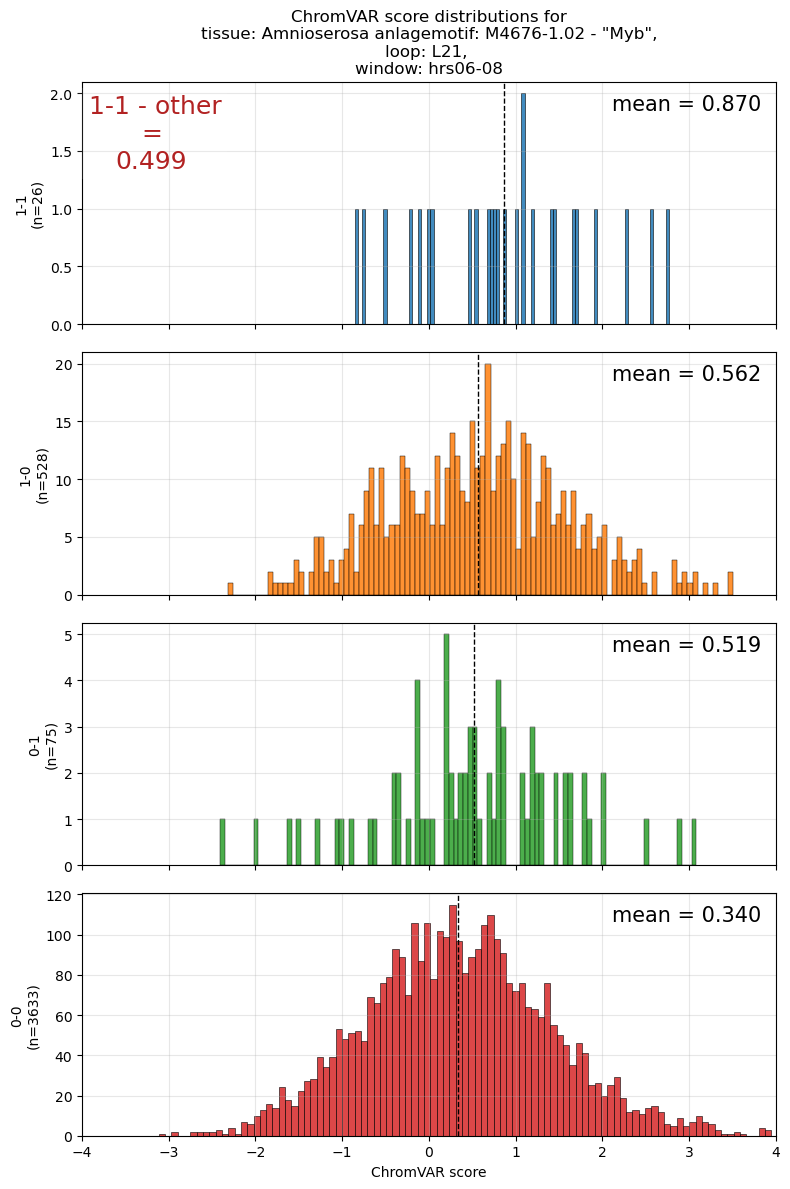

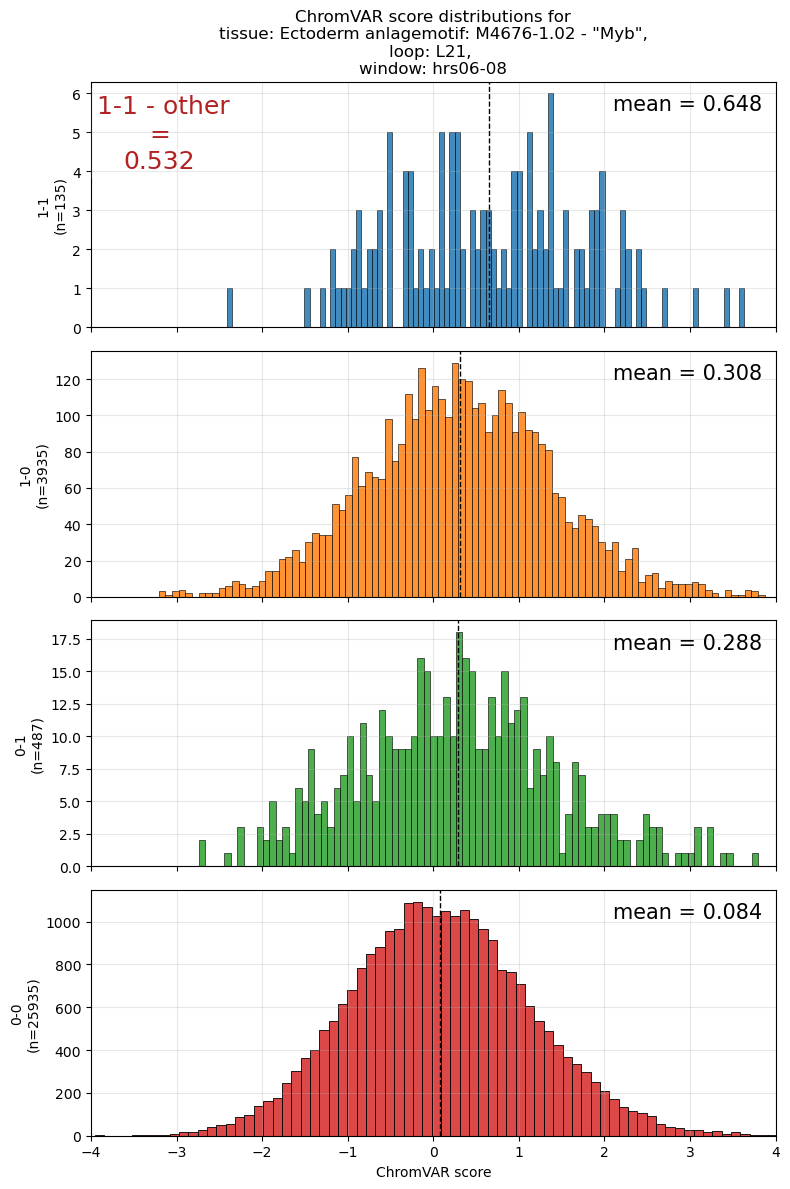

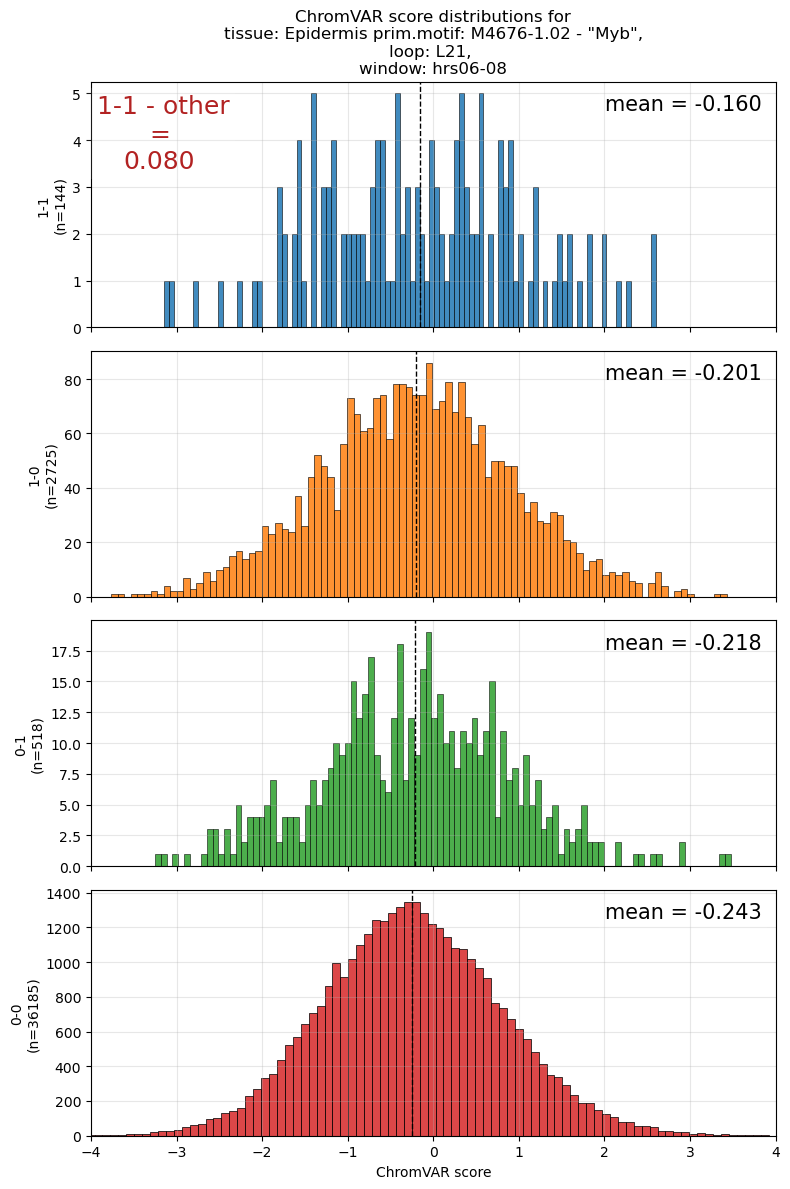

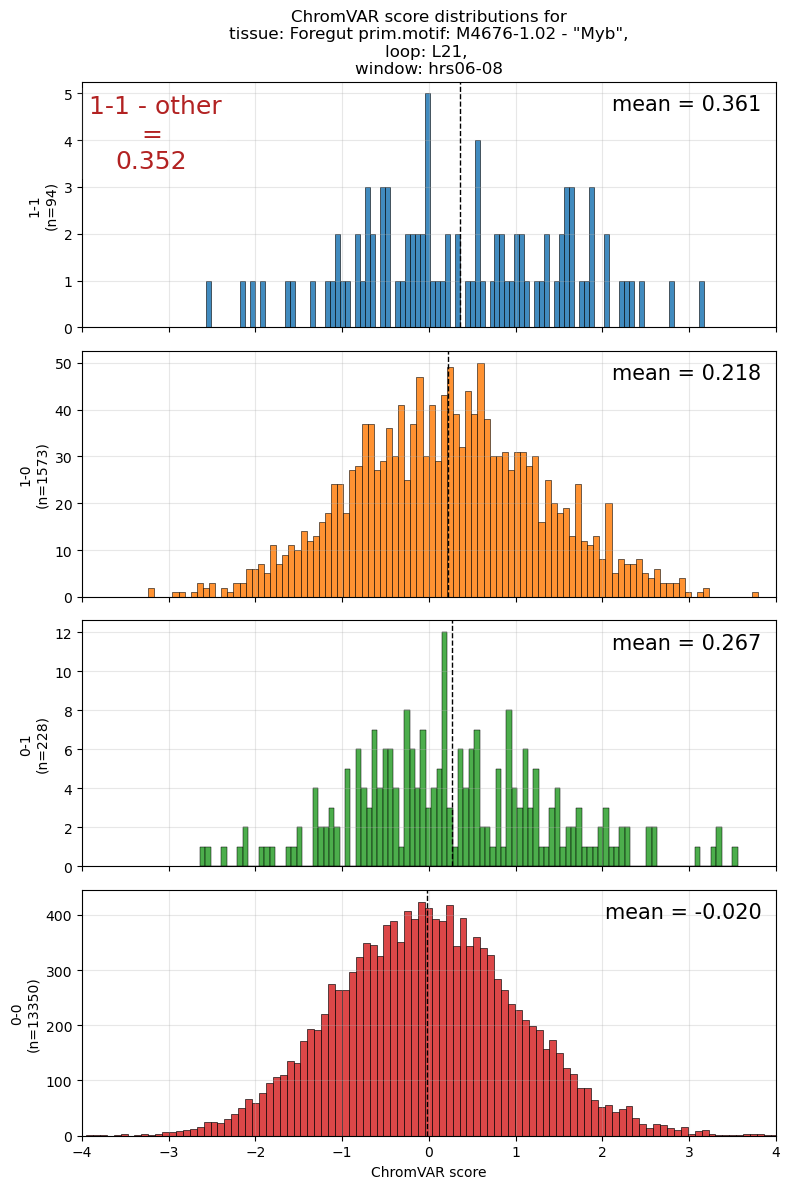

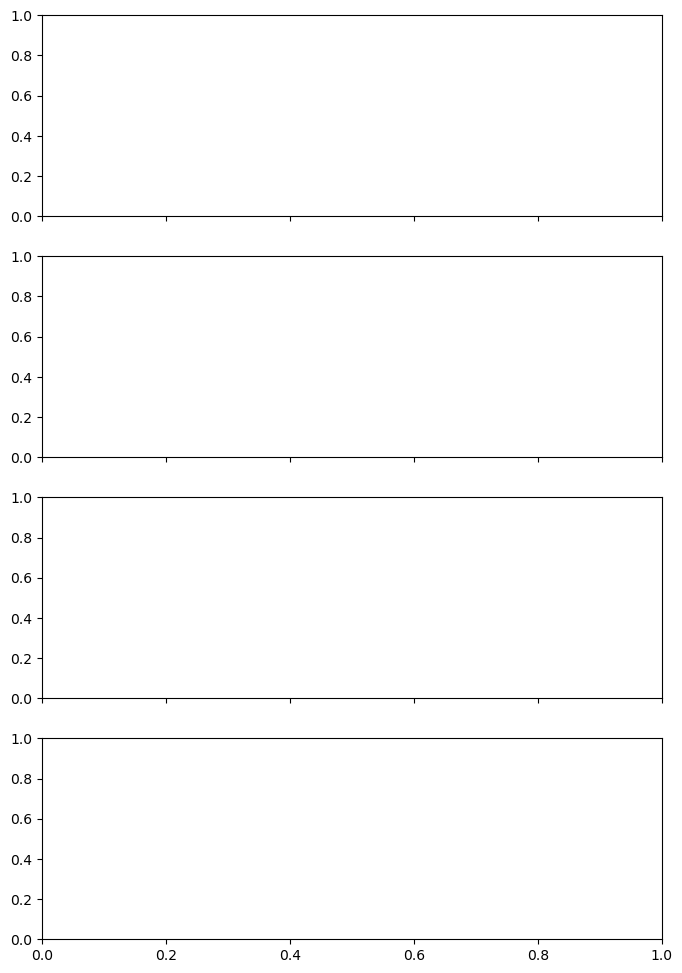

In [60]:
curr_plotting_dict = big_dict_stratified

for loop_id in loop_ids:
    for motif_id in motif_ids:
        motif_name = motif_lookup[motif_lookup["id"] == motif_id]["name"]
        motif_name = str(list(motif_name)[0])
        for window in windows:
            # print(f"{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\t\t Creating the plot for {loop_id}, {motif_id}, {window}\n")

            for annotation in curr_plotting_dict[window].keys():
                plot_distributions(window=window, loop_id=loop_id,
                                motif_id=motif_id, motif_name=motif_name,
                                big_dict=curr_plotting_dict,
                                tissue_annotation=annotation,
                                figure_dir=f"results/figures/chromvar_distributions/refined_annotations/{annotation}",
                                save=True)